In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import re
from utility import extract_case_features, extract_linguistic_features

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
upper_count, upper_ratio = zip(*df["text"].apply(extract_case_features))
upper_count = pd.Series(upper_count, name="upper_count")
upper_ratio = pd.Series(upper_ratio, name="upper_ratio")
df_with_upper_count = pd.concat([df, upper_count, upper_ratio], axis=1)

df_with_upper_count


KeyboardInterrupt



In [ ]:
uppercase_per_label = df_with_upper_count.groupby("label").agg({"upper_count": "sum", "upper_ratio": "mean"})

uppercase_per_label

,upper_count,upper_ratio
label,,
Non-Suicidal,6953,0.008862
Suicidal,8155,0.008668


Text(0.5, 0.98, 'Uppercase_count and Ratio per Label')

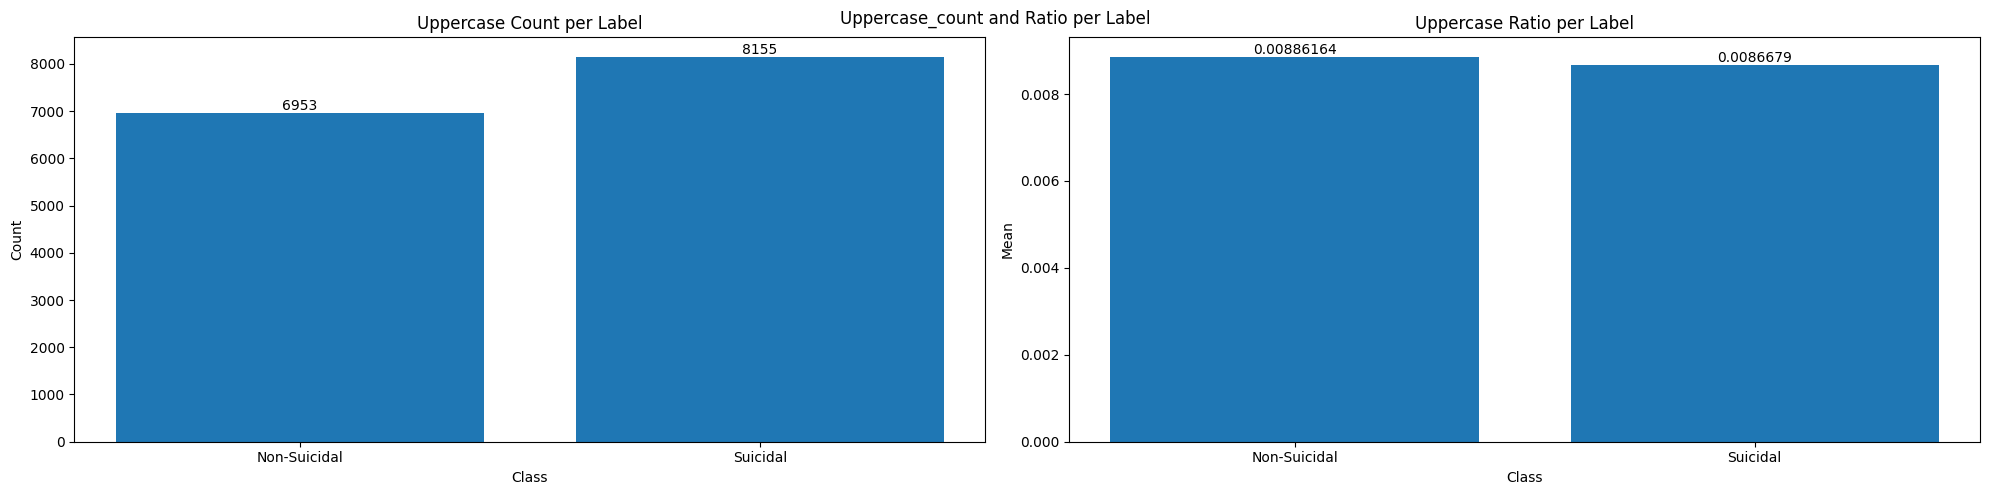

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

count_bars = ax[0].bar(x=uppercase_per_label["upper_count"].index, height=uppercase_per_label["upper_count"])
ax[0].bar_label(count_bars)
ax[0].set_title("Uppercase Count per Label")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

ratio_bars = ax[1].bar(x=uppercase_per_label["upper_ratio"].index, height=uppercase_per_label["upper_ratio"])
ax[1].bar_label(ratio_bars)
ax[1].set_title("Uppercase Ratio per Label")
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Mean")

fig.tight_layout()
fig.suptitle("Uppercase_count and Ratio per Label")

Non-suicidal posts have less uppercase word counts, although their word ratio are similar on average.  We keep those elements since they matter in conveying emotion. However, since it may cause overhead for traditional ml models, we will create a separate column with the text all lowercase, but we will retain the counts and ratios for reference. For deeper models like neural networks, we retain them.

In [ ]:
# Has emojis
emoji_count = df["text"].str.contains(r":\)|:\(|:\/").sum()
emoji_count

np.int64(860)

In [ ]:
print(f"Amount of instances with emojis: {emoji_count / df.shape[0] * 100 : .2f}%") # Might be more since only captures :), :(, and :/

Amount of instances with emojis:  5.56%


Emoji count is not as significant, but we will add these as features for more information.

Given what we have seen, we will make a unified clean_reddit_post function and put it in new column.